# １章４節３項 マルチルック処理

## 概要
SAR画像特有のスペックルノイズを低減するためのマルチルック処理を実装します。
空間分解能でのマルチルック処理と時間分解能でのマルチルック処理の両方を実施します。

## 使用データ

| 項目 | 情報 |
| ---- | ---- |
| 衛星 | Sentinel-1 |
| データパス | /work/data/multilook/ |
| データ形式 | GeoTIFF (VV偏波、gamma0、デシベル値) |
| 画像クレジット | Contains modified Copernicus Sentinel data |

In [1]:
# 必要なライブラリのインポート
import os
import glob
import warnings

import numpy as np
import xarray as xr
import rioxarray
import japanize_matplotlib
import matplotlib.pyplot as plt

# 警告メッセージを非表示
warnings.filterwarnings('ignore')

In [2]:
# 入力データと出力先のパス設定
PATH_INPUT = '/work/data/multilook/'
PATH_OUTPUT = '/work/outputs/multilook/'

# 出力ディレクトリが存在しない場合は作成
os.makedirs(PATH_OUTPUT, exist_ok=True)

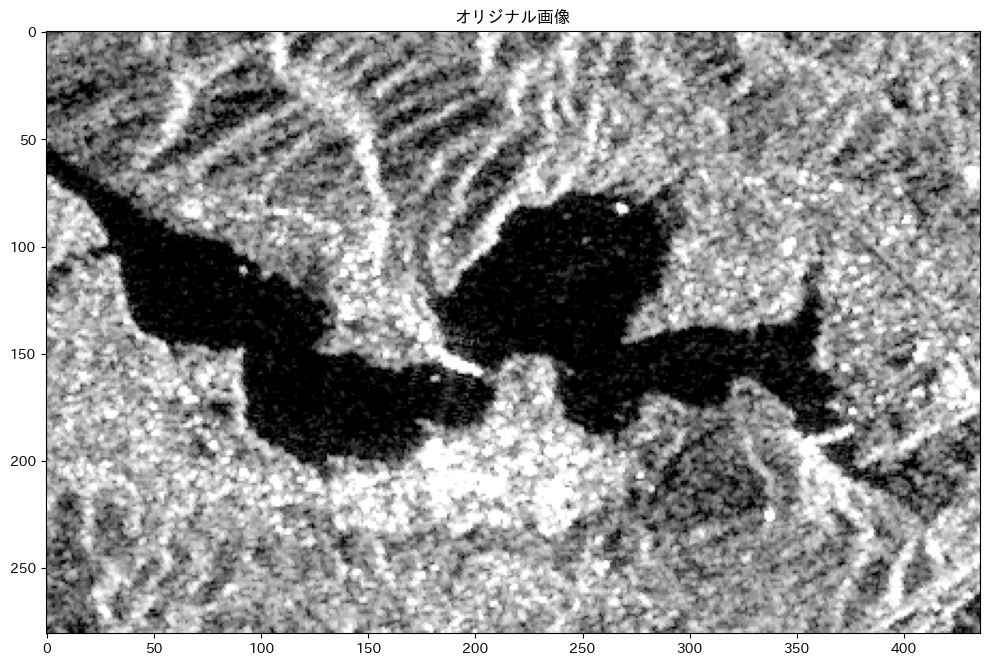

In [3]:
# Sentinel-1画像データの読み込み
data = os.path.join(PATH_INPUT, '2024-09-09-00_00_2024-09-09-23_59_Sentinel-1_AWS-IW-VVVH_VV_-_decibel_gamma0.tiff')

# rioxarrayで画像を読み込む
img_xr = rioxarray.open_rasterio(data)
# numpy配列に変換（バンド0を取得）
img = img_xr.isel(band=0).values.astype(np.uint16)

# 可視化用のパーセンタイル値を計算
p2, p98 = np.nanpercentile(img, [2, 98])

# オリジナル画像を可視化
plt.figure(figsize=(10, 10))
plt.imshow(img, cmap='gray', vmin=p2, vmax=p98)
plt.title('オリジナル画像')
plt.savefig(os.path.join(PATH_OUTPUT, 'figure13.png'))
plt.tight_layout()
plt.show()

In [4]:
def multilooking(img, n_looks):
    """
    空間分解能でのマルチルック処理を行う関数
    
    Parameters:
    -----------
    img : ndarray
        入力画像
    n_looks : int
        マルチルック数（n_looks × n_looks のウィンドウで平均化）
    
    Returns:
    --------
    multilooked_img : ndarray
        マルチルック処理後の画像
    """
    h, w = img.shape
    # n_looksで割り切れるサイズに調整
    new_h = h - (h % n_looks)
    new_w = w - (w % n_looks)

    img_clipped = img[:new_h, :new_w]

    # 画像を n_looks × n_looks のブロックに分割し、平均化
    reshaped_img = img_clipped.reshape((img_clipped.shape[0] // n_looks), n_looks, img_clipped.shape[1] // n_looks, n_looks)
    multilooked_img = reshaped_img.mean(axis=(1, 3))

    return multilooked_img

In [5]:
# 異なるマルチルック数で処理を実行
multilooked_img_4 = multilooking(img, 4)
multilooked_img_6 = multilooking(img, 6)
multilooked_img_8 = multilooking(img, 8)

# 各画像の分散を計算して比較
print('分散の比較:')
print(f'オリジナル画像: {np.var(img):.2f}')
print(f'4ピクセルマルチルック: {np.var(multilooked_img_4):.2f}')
print(f'6ピクセルマルチルック: {np.var(multilooked_img_6):.2f}')
print(f'8ピクセルマルチルック: {np.var(multilooked_img_8):.2f}')

分散の比較:
オリジナル画像: 361551654.22
4ピクセルマルチルック: 298968376.06
6ピクセルマルチルック: 276976364.94
8ピクセルマルチルック: 257551872.18


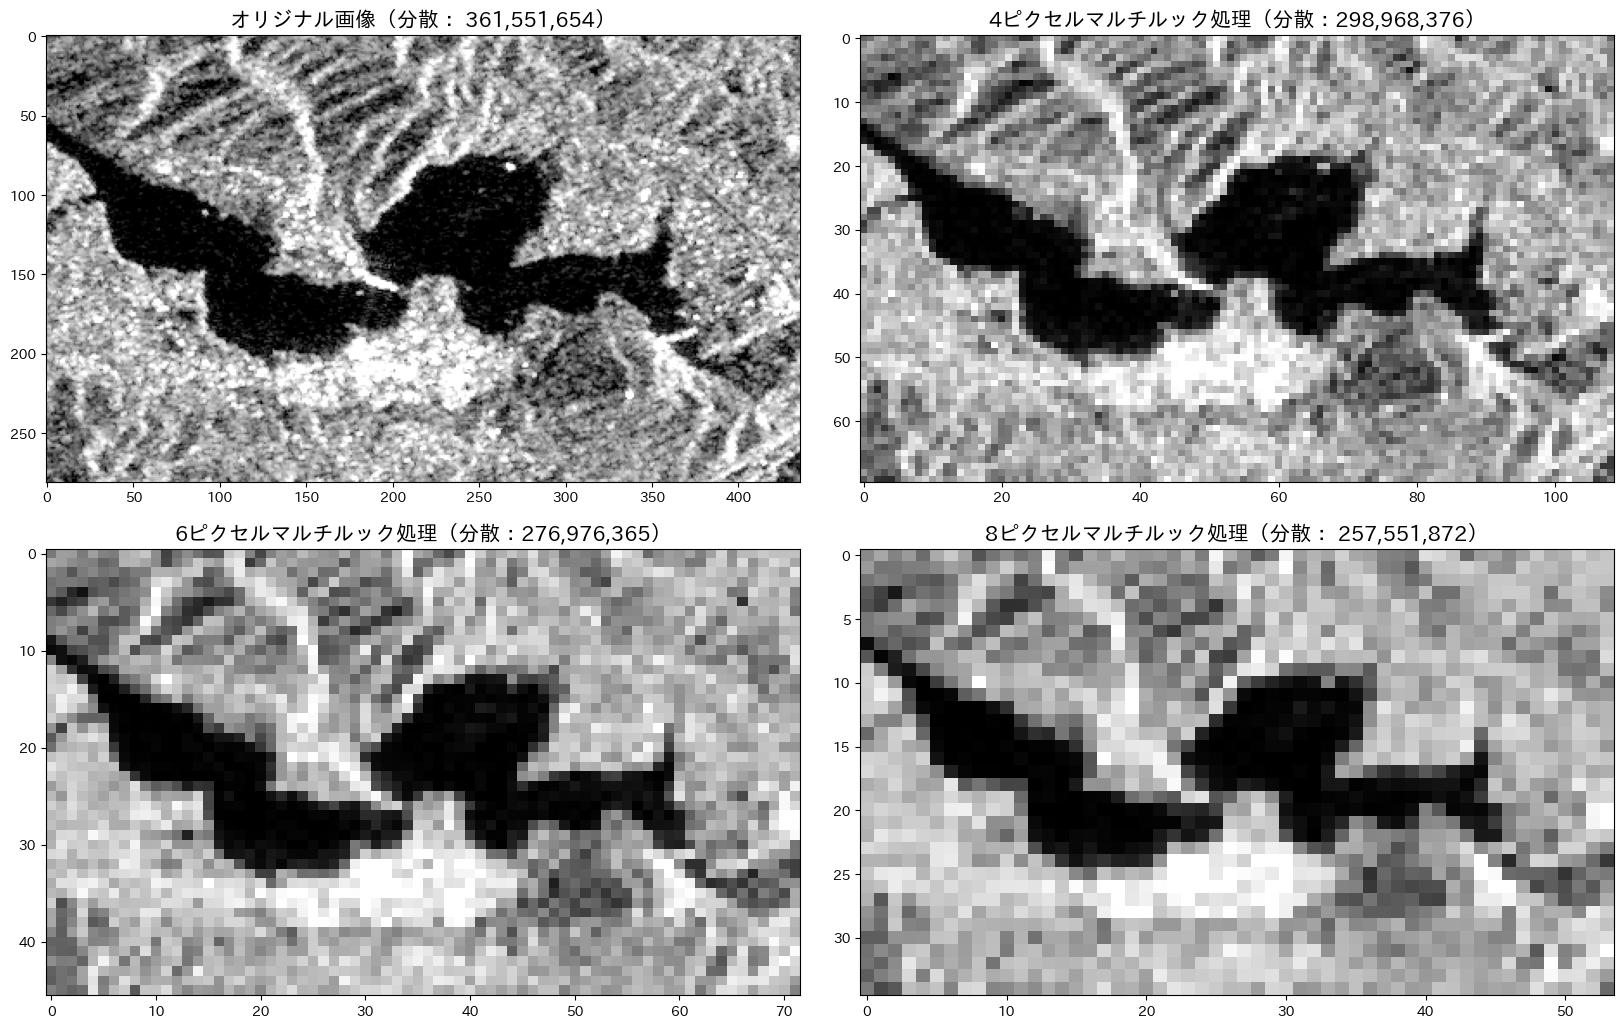

In [ ]:
# 空間マルチルック処理の比較可視化（2×2グリッド）
fig, axes = plt.subplots(2, 2, figsize=(16, 10),
                         gridspec_kw={'wspace': 0.08, 'hspace': 0.15})

# 各画像の分散を計算
var_original = np.var(img)
var_4 = np.var(multilooked_img_4)
var_6 = np.var(multilooked_img_6)
var_8 = np.var(multilooked_img_8)

# 可視化用のパーセンタイル値を計算
p2_orig, p98_orig = np.nanpercentile(img, [2, 98])
p2_4, p98_4 = np.nanpercentile(multilooked_img_4, [2, 98])
p2_6, p98_6 = np.nanpercentile(multilooked_img_6, [2, 98])
p2_8, p98_8 = np.nanpercentile(multilooked_img_8, [2, 98])

# 左上: オリジナル画像
axes[0, 0].imshow(img, cmap='gray', vmin=p2_orig, vmax=p98_orig, aspect='auto')
axes[0, 0].set_title(f'オリジナル画像（分散： {var_original:,.0f}）', fontsize=15, pad=6)

# 右上: 4ピクセルマルチルック
axes[0, 1].imshow(multilooked_img_4, cmap='gray', vmin=p2_4, vmax=p98_4, aspect='auto')
axes[0, 1].set_title(f'4ピクセルマルチルック処理（分散：{var_4:,.0f}）', fontsize=15, pad=6)

# 左下: 6ピクセルマルチルック
axes[1, 0].imshow(multilooked_img_6, cmap='gray', vmin=p2_6, vmax=p98_6, aspect='auto')
axes[1, 0].set_title(f'6ピクセルマルチルック処理（分散：{var_6:,.0f}）', fontsize=15, pad=6)

# 右下: 8ピクセルマルチルック
axes[1, 1].imshow(multilooked_img_8, cmap='gray', vmin=p2_8, vmax=p98_8, aspect='auto')
axes[1, 1].set_title(f'8ピクセルマルチルック処理（分散： {var_8:,.0f}）', fontsize=15, pad=6)

plt.subplots_adjust(left=0.01, right=0.99, top=0.97, bottom=0.01)
plt.savefig(os.path.join(PATH_OUTPUT, 'figure14.png'), dpi=150, bbox_inches='tight')
plt.show()

# 時間分解能でのマルチルック処理

In [7]:
# 時間分解能マルチルック用のファイル検索
INPUT_DIRECTORY = PATH_INPUT

# 入力ディレクトリ内のすべてのTIFFファイルを検索
search_criteria = os.path.join(INPUT_DIRECTORY, '*.tiff')
tiff_files = sorted(glob.glob(search_criteria), reverse=True)

print(f'検出されたファイル数: {len(tiff_files)}')

検出されたファイル数: 9


In [8]:
def time_multilooking(image_paths):
    """
    時間分解能でのマルチルック処理を行う関数
    
    Parameters:
    -----------
    image_paths : list
        画像ファイルパスのリスト
    
    Returns:
    --------
    avg_image : xarray.DataArray
        時間方向で平均化された画像
    """
    # 各画像をxarrayデータセットとして読み込む
    datasets = [rioxarray.open_rasterio(path) for path in image_paths]
    
    # 時間次元で結合
    combined = xr.concat(datasets, dim='time')
    # 時間方向で平均化
    avg_image = combined.mean(dim='time')

    # 元のデータ型に変換
    avg_image = avg_image.astype(datasets[0].dtype)
    
    return avg_image

In [16]:
# 異なる画像数でマルチルック処理を実行
multilooked_1 = rioxarray.open_rasterio(tiff_files[0])  # 単一画像（最新）
multilooked_4 = time_multilooking(tiff_files[:4])  # 4画像平均
multilooked_6 = time_multilooking(tiff_files[:6])  # 6画像平均
multilooked_8 = time_multilooking(tiff_files[:8])  # 8画像平均

# 各画像の分散を計算して比較
print('分散の比較:')
print(f'オリジナル画像: {np.var(img):.2f}')
print(f'4ピクセルマルチルック: {np.var(multilooked_4):.2f}')
print(f'6ピクセルマルチルック: {np.var(multilooked_6):.2f}')
print(f'8ピクセルマルチルック: {np.var(multilooked_8):.2f}')

分散の比較:
オリジナル画像: 361551654.22
4ピクセルマルチルック: 311015120.87
6ピクセルマルチルック: 310751578.33
8ピクセルマルチルック: 309626856.51


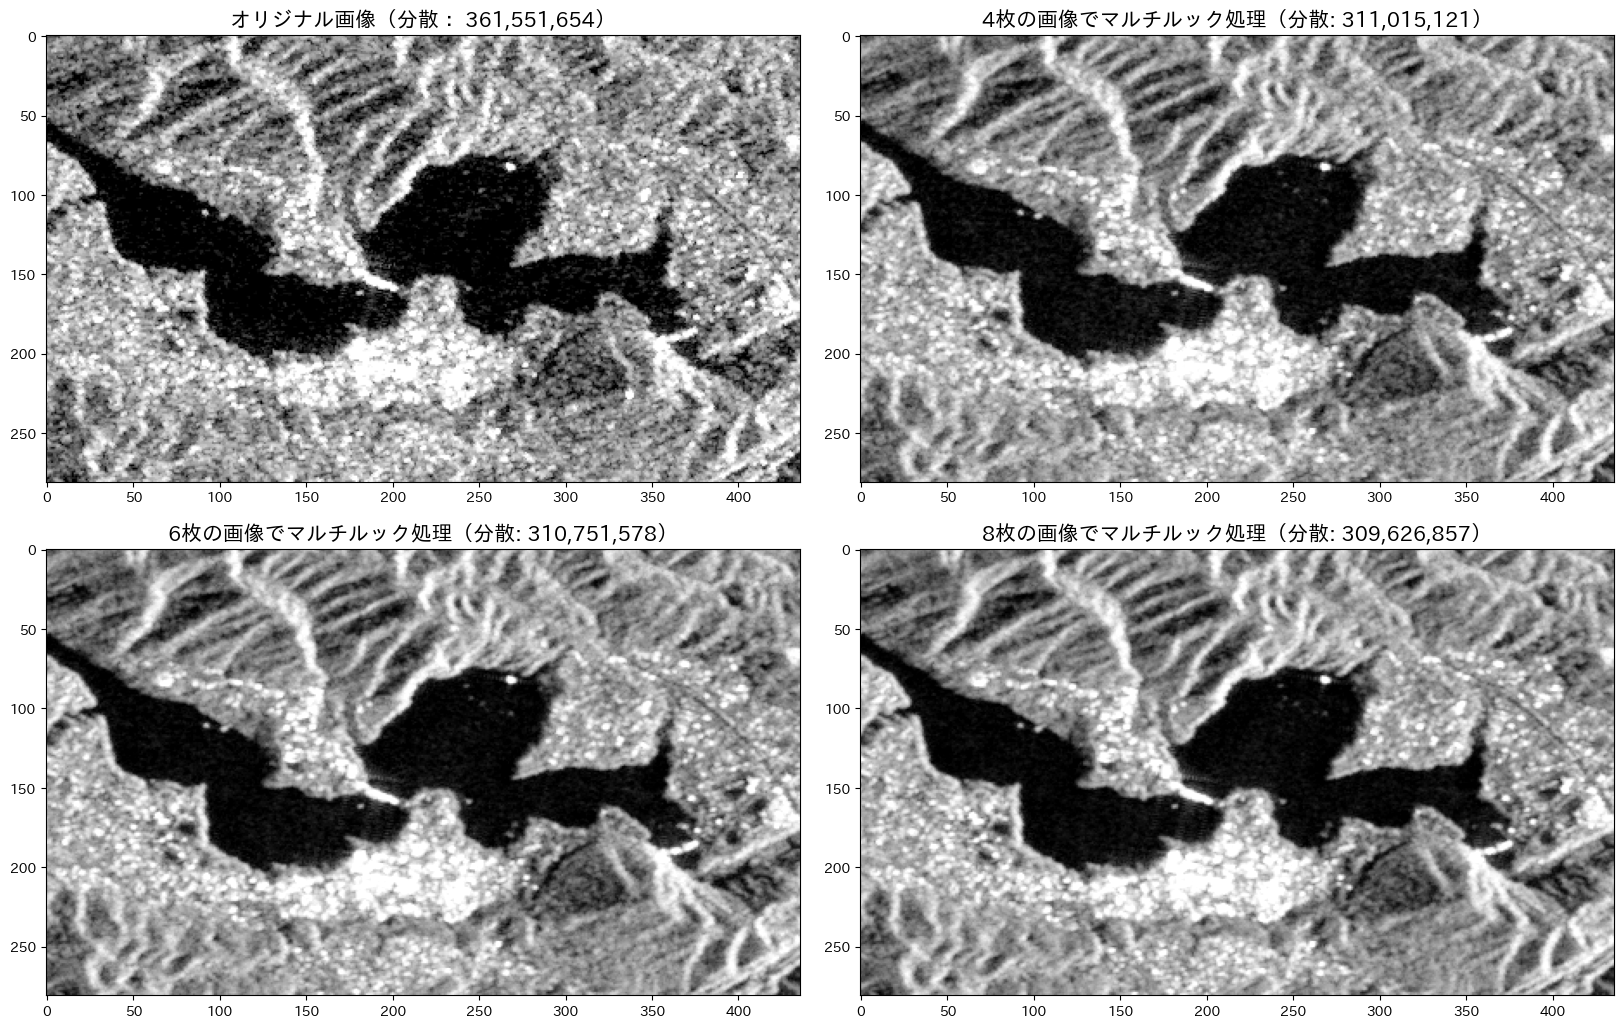

In [17]:
# 時間分解能マルチルック処理の比較可視化（2×2グリッド）
# 図とサブプロットの作成
fig, axes = plt.subplots(2, 2, figsize=(16, 10),
                         gridspec_kw={'wspace': 0.08, 'hspace': 0.15})

# 各画像の分散を計算
var_1 = np.var(multilooked_1)
var_4 = np.var(multilooked_4)
var_6 = np.var(multilooked_6)
var_8 = np.var(multilooked_8)

# 可視化用のパーセンタイル値を計算
p2_1, p98_1 = np.nanpercentile(multilooked_1, [2, 98])
p2_4, p98_4 = np.nanpercentile(multilooked_4, [2, 98])
p2_6, p98_6 = np.nanpercentile(multilooked_6, [2, 98])
p2_8, p98_8 = np.nanpercentile(multilooked_8, [2, 98])

# 左上: 単一画像（最新）
axes[0, 0].imshow(multilooked_1.isel(band=0), cmap='gray', vmin=p2_1, vmax=p98_1, aspect='auto')
axes[0, 0].set_title(f'オリジナル画像（分散： {var_1:,.0f}）', fontsize=15, pad=6)

# 右上: 4画像マルチルック
axes[0, 1].imshow(multilooked_4.isel(band=0), cmap='gray', vmin=p2_4, vmax=p98_4, aspect='auto')
axes[0, 1].set_title(f'4枚の画像でマルチルック処理（分散: {var_4:,.0f}）', fontsize=15, pad=6)

# 左下: 6画像マルチルック
axes[1, 0].imshow(multilooked_6.isel(band=0), cmap='gray', vmin=p2_6, vmax=p98_6, aspect='auto')
axes[1, 0].set_title(f'6枚の画像でマルチルック処理（分散: {var_6:,.0f}）', fontsize=15, pad=6)
# 右下: 8画像マルチルック
axes[1, 1].imshow(multilooked_8.isel(band=0), cmap='gray', vmin=p2_8, vmax=p98_8, aspect='auto')
axes[1, 1].set_title(f'8枚の画像でマルチルック処理（分散: {var_8:,.0f}）', fontsize=15, pad=6)

plt.subplots_adjust(left=0.01, right=0.99, top=0.97, bottom=0.01)
plt.savefig(os.path.join(PATH_OUTPUT, 'figure15.png'), dpi=150, bbox_inches='tight')
plt.show()